In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [2]:
x,y,z,vx,vy,vz = np.loadtxt("particle_pos_vel.txt",unpack=True)

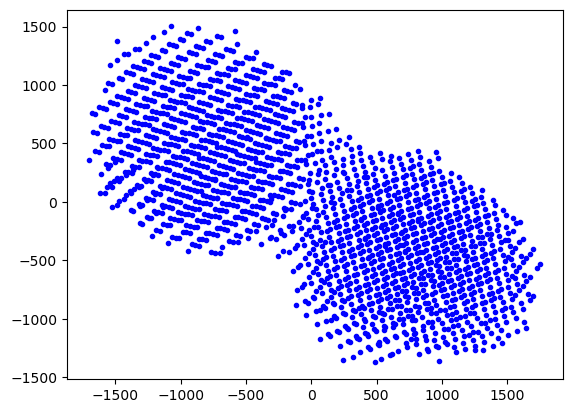

In [3]:
plt.plot(x,y,'b.')

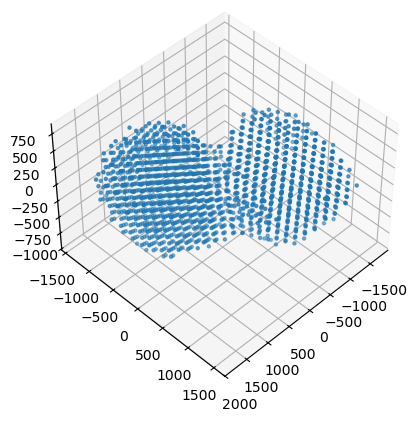

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z,marker='.')
ax.view_init(45,45)

In [5]:
L = np.array([1,2,3])
I = np.array([[1,2,3],[4,5,6],[7,8,9]])

print(L)
print(I)

C = np.dot(I,L)

print(C)

[1 2 3]
[[1 2 3]
 [4 5 6]
 [7 8 9]]
[14 32 50]


In [6]:

print(L)
print(I)

[1 2 3]
[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [7]:
a = np.array([1,2,3])
b = np.array([2,3,4])
c = np.cross(a,b)
d = np.dot(a,a)

print(c,d)
#print(iden)

[-1  2 -1] 14


In [23]:
L = np.zeros(3)
I = np.zeros((3,3))
iden = np.identity(3)

for i in range(x.size):
    r = np.array([x[i],y[i],z[i]])
    v = np.array([vx[i],vy[i],vz[i]])

    L += np.cross(r,v)
    I += np.dot(r,r)*iden - np.outer(r,r)

print(L)
print(I)

[-3.08987967e+03 -2.40005076e+02 -9.23896671e+05]
[[ 1.05814019e+09  7.38005013e+08 -1.26285498e+07]
 [ 7.38005013e+08  1.73974331e+09 -1.29502785e+06]
 [-1.26285498e+07 -1.29502785e+06  2.28012205e+09]]


In [9]:
import scipy.linalg as linalg

In [10]:
I_inverse = linalg.inv(I)

In [11]:
omega = np.dot(I_inverse,L)

In [12]:
2*np.pi/omega/3600

2*np.pi/(np.dot(omega,omega)**0.5)/3600

np.float64(4.30508864203045)

In [13]:
print(L)
print(omega)

[-3.08987967e+03 -2.40005076e+02 -9.23896671e+05]
[-1.05803868e-05  4.04862038e-06 -4.05252449e-04]


In [22]:

print(2*np.pi/np.abs(omega)/3600.)

[164.95892669 431.0923449    4.3067704 ]


In [14]:
np.savetxt("particle_pos_vel.txt",np.transpose([x,y,z,vx,vy,vz]),delimiter='\t',
           header = " x, y, z, vx, vy, vz (all in SI - distances in m, velocity  m/s)",fmt='%.6f')